# Tanzania Water Pumps - Predicting & Prioritizing Repairs

Thousands of communities in Tanzania depend on water pumps for clean water, yet
a large share are broken or failing. This notebook builds a model that predicts
each pump's status so authorities can **target repairs where they matter most**.

**Data:** [DrivenData "Pump it Up"](https://www.drivendata.org/competitions/7/pump-it-up-data-mining-the-water-table/) 59,400 labeled pumps, 40 features, 3 class target.

**Approach:** clean, leak-free feature engineering (in `src/`) + tree-based models.
This notebook shows the story; the reusable code lives in the `src/` package.

## 1. Setup

In [1]:
import sys
from pathlib import Path

# Make the src/ package importable no matter where the notebook runs from.
ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import config as C
from src import data as D
from src import model as M
from src.features import FeatureEngineer

sns.set_theme(style="whitegrid", context="talk")
PALETTE = {"functional": "#2a9d8f", "non functional": "#e76f51",
           "functional needs repair": "#e9c46a"}

## 2. Load the data

In [2]:
df = D.load_training()
print(f"{df.shape[0]:,} pumps  x  {df.shape[1]} columns")
df[["amount_tsh", "gps_height", "population",
    "construction_year", "quantity", "status_group"]].head()

59,400 pumps  x  41 columns


,amount_tsh,gps_height,population,construction_year,quantity,status_group
0,6000.0,1390,109,1999,enough,functional
1,0.0,1399,280,2010,insufficient,functional
2,25.0,686,250,2009,enough,functional
3,0.0,263,58,1986,dry,non functional
4,0.0,0,0,0,seasonal,functional


## 3. The target is imbalanced

Pumps fall into three states. The **"needs repair"** class is rare (~7%) but the
most valuable to catch early — a pump caught here can be fixed before it fails
and leaves a village without water.

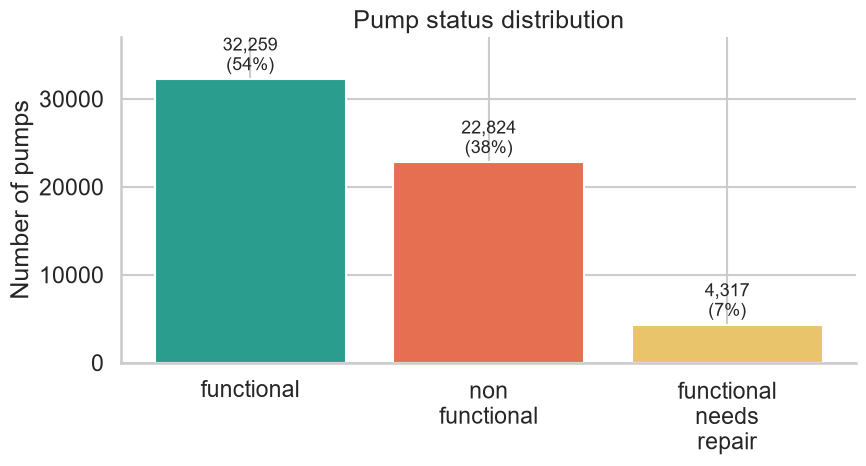

In [3]:
order = ["functional", "non functional", "functional needs repair"]
counts = df["status_group"].value_counts().reindex(order)

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(range(len(counts)), counts.values,
       color=[PALETTE[c] for c in counts.index])
ax.set_xticks(range(len(counts)))
ax.set_xticklabels([c.replace(" ", "\n") for c in counts.index])
for i, v in enumerate(counts.values):
    ax.text(i, v + 400, f"{v:,}\n({v/len(df)*100:.0f}%)",
            ha="center", va="bottom", fontsize=13)
ax.set_ylabel("Number of pumps")
ax.set_title("Pump status distribution")
ax.set_ylim(0, counts.max() * 1.15)
sns.despine()
plt.tight_layout()
plt.show()

## 4. Data quality: hidden missing values

Many columns store missing data as **zeros** rather than blanks. For example,
`construction_year = 0` or `longitude = 0` are impossible real values. Spotting
these matters — treating them as real numbers would mislead the model.

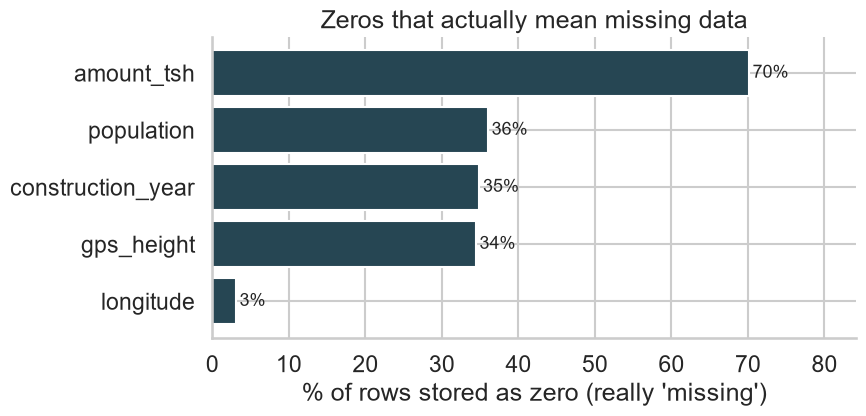

In [4]:
zero_as_missing = ["construction_year", "longitude", "gps_height",
                   "population", "amount_tsh"]
zero_pct = {c: (df[c] == 0).mean() * 100 for c in zero_as_missing}
zero_pct = pd.Series(zero_pct).sort_values()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(zero_pct.index, zero_pct.values, color="#264653")
for i, v in enumerate(zero_pct.values):
    ax.text(v + 0.5, i, f"{v:.0f}%", va="center", fontsize=13)
ax.set_xlabel("% of rows stored as zero (really 'missing')")
ax.set_title("Zeros that actually mean missing data")
ax.set_xlim(0, max(zero_pct.values) * 1.2)
sns.despine()
plt.tight_layout()
plt.show()

## 5. Where are the pumps?

Each pump has GPS coordinates. Plotting them draws the map of Tanzania, and
failures are **not spread evenly** — some regions have visibly more broken
pumps. Location will turn out to be one of the strongest predictors.

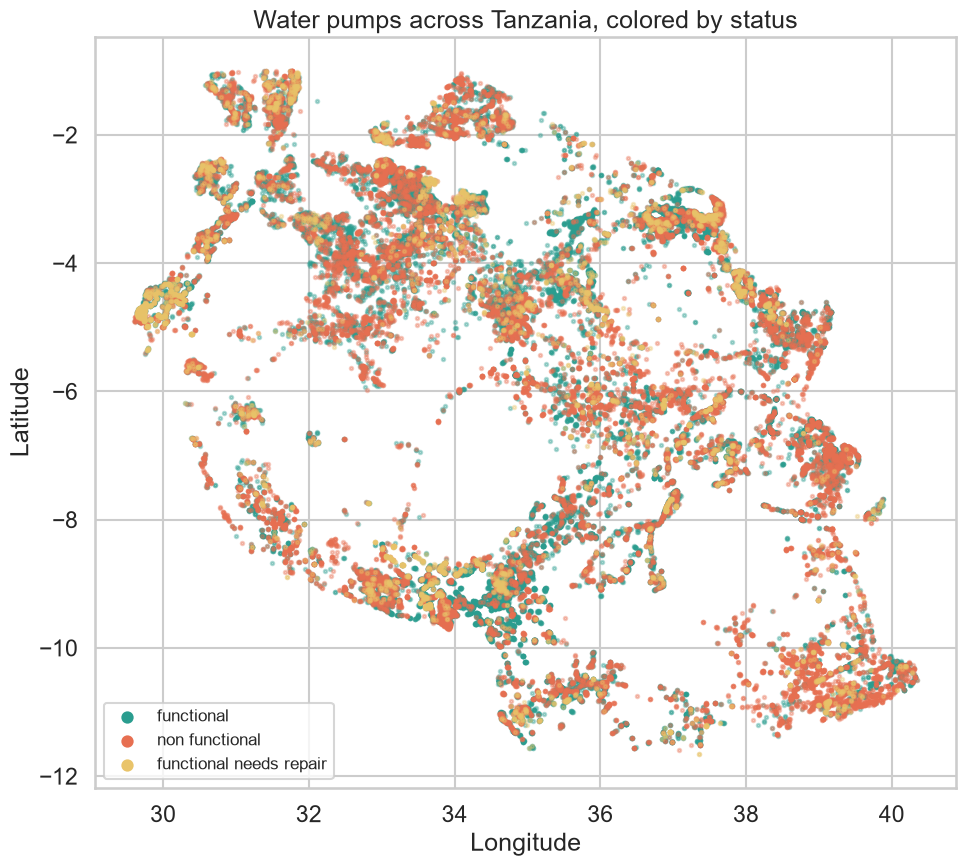

In [5]:
geo = df[(df["longitude"] > 25) & (df["latitude"] < -0.5)]  # drop invalid 0,0 points

fig, ax = plt.subplots(figsize=(10, 9))
for status in order:
    s = geo[geo["status_group"] == status]
    ax.scatter(s["longitude"], s["latitude"], s=6, alpha=0.35,
               color=PALETTE[status], label=status)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Water pumps across Tanzania, colored by status")
leg = ax.legend(markerscale=3, fontsize=12, loc="lower left")
for lh in leg.legend_handles:
    lh.set_alpha(1)
plt.tight_layout()
plt.show()

## 6. Avoiding a data-leakage trap

A subtle but critical detail: some features are **encoded using statistics
learned from the data** (e.g. how frequent a funder is). If those statistics are
computed over the *whole* dataset — including the validation and competition
rows — the model secretly "sees" data it should not, and scores look better than
they really are.

**The fix:** split first, then learn every encoder on the **training split only**
and apply it to the rest. The `FeatureEngineer` class enforces this: it `fit`s on
train and `transform`s everything else.

In [6]:
from sklearn.model_selection import train_test_split

y = D.encode_target(df[C.TARGET])
X = df.drop(columns=[C.TARGET])

# 1) Split BEFORE any encoding.
X_tr_raw, X_val_raw, y_tr, y_val = train_test_split(
    X, y, test_size=C.TEST_SIZE, random_state=C.RANDOM_STATE, stratify=y)

# 2) Fit feature engineering on TRAIN only, then transform the rest.
fe = FeatureEngineer()
X_tr = fe.fit_transform(X_tr_raw)
X_val = fe.transform(X_val_raw)

print(f"Train: {X_tr.shape} | Validation: {X_val.shape}")
print(f"{X_tr.shape[1]} numeric features after encoding")

Train: (47520, 138) | Validation: (11880, 138)
138 numeric features after encoding


## 7. Modeling & results

Two tree-based models, both using per-class weighting to handle the imbalance.
We report **macro F1** (treats all classes equally, so the rare class counts)
and **ROC AUC**, not just accuracy.

In [7]:
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             confusion_matrix)

rf = M.train_random_forest(X_tr, y_tr)
lgbm = M.train_lightgbm(X_tr, y_tr, X_val, y_val)

def scores(m, name):
    pred = m.predict(X_val)
    proba = m.predict_proba(X_val)
    return {"Model": name,
            "Accuracy": accuracy_score(y_val, pred),
            "Macro F1": f1_score(y_val, pred, average="macro"),
            "F1 (needs repair)": f1_score(y_val, pred, labels=[2], average="macro"),
            "ROC AUC": roc_auc_score(y_val, proba, multi_class="ovr")}

results = pd.DataFrame([scores(rf, "Random Forest"), scores(lgbm, "LightGBM")])

# Everything below uses whichever model wins on macro F1, so the notebook can
# never disagree with the pipeline about which model it is describing.
best_name = results.set_index("Model")["Macro F1"].idxmax()
best = {"Random Forest": rf, "LightGBM": lgbm}[best_name]

results.set_index("Model").round(3)


,Accuracy,Macro F1,F1 (needs repair),ROC AUC
Model,,,,
Random Forest,0.796,0.702,0.456,0.904
LightGBM,0.786,0.697,0.455,0.902


The confusion matrix below shows where the best model succeeds and struggles.
It handles `functional` and `non functional` well; `needs repair` stays the
hardest — it is rare and looks similar to the other two.

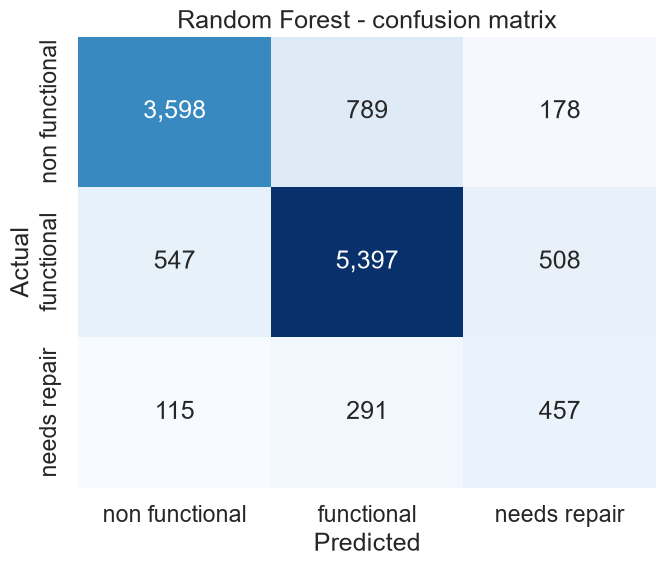

In [8]:
labels = [0, 1, 2]
names = ["non functional", "functional", "needs repair"]
cm = confusion_matrix(y_val, best.predict(X_val), labels=labels)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues",
            xticklabels=names, yticklabels=names, cbar=False, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"{best_name} - confusion matrix")
plt.tight_layout()
plt.show()


## 8. What drives pump failure?

The model's most important signals are intuitive: **water quantity** (a dry pump
is almost always non-functional), **location**, **pump age**, and **who funded
or installed it**.

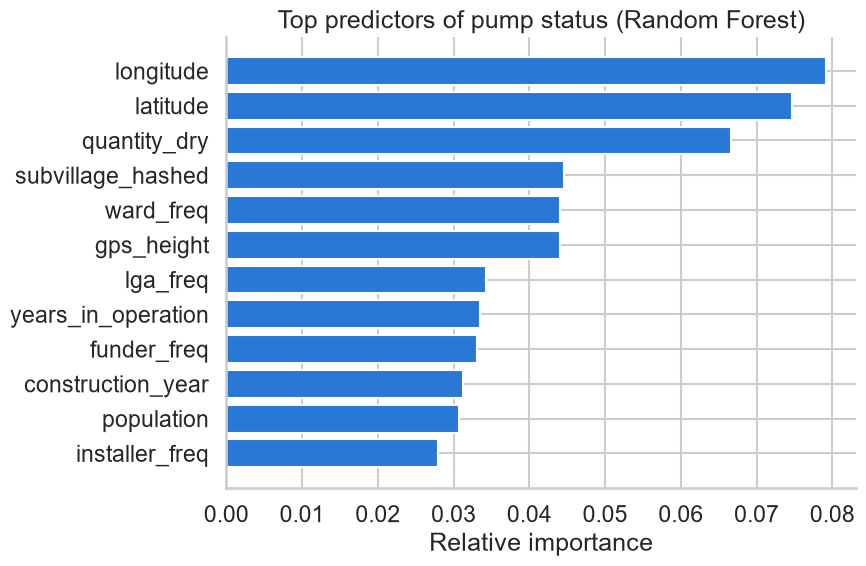

In [9]:
imp = M.feature_importance(best, X_tr.columns, top=12).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(imp.index, imp.values, color="#2a78d6")
ax.set_xlabel("Relative importance")
ax.set_title(f"Top predictors of pump status ({best_name})")
sns.despine()
plt.tight_layout()
plt.show()


## 9. From probabilities to repair decisions

A macro F1 of 0.70 does not tell a water authority what to do on Monday. Two
questions do.

**First: with a limited budget, how well is it spent?** Crews cannot visit
59,000 pumps, so rank them by risk - `P(non functional) + P(needs repair)` -
and walk down the list. `precision@k` is the share of the top *k* that
genuinely need work; `lift@k` states it as a multiple of inspecting at random.

In [10]:
from src import decision as DEC

proba = best.predict_proba(X_val)
DEC.ranking_report(y_val, proba).round(3)

,precision@k,recall@k,lift@k
inspections (k),,,
500,0.996,0.092,2.180
1000,0.992,0.183,2.171
2500,0.974,0.448,2.131
5000,0.834,0.768,1.824


Sending crews to the top 1,000 ranked pumps finds ~993 that genuinely need
work; 1,000 random inspections find ~457. The ranking more than doubles the
return on every crew-day.

**Second: are we optimising for the right mistake?** `argmax P(class)` assumes
every error costs the same. It does not - leaving a broken pump unvisited
strands a village for months, while a wasted inspection costs one crew-day.
Pricing that asymmetry and minimising *expected cost* instead:

In [11]:
DEC.cost_comparison(y_val, proba).round(2)

,accuracy,missed broken pumps,wasted visits,total cost
decision rule,,,,
argmax P(class),0.80,1080,1055,10693.0
min expected cost,0.54,45,4910,5757.0


Same model, same probabilities - only the decision rule changed. It misses far
fewer broken pumps and cuts total cost substantially, while **accuracy drops**.

That is the point, not a bug: accuracy is the wrong objective here, and
optimising it would have quietly left a thousand villages without water.

## 10. Conclusions & next steps

**What we built:** a reproducible, leak-free pipeline that predicts pump status
with **macro F1 ~ 0.70** and **ROC AUC ~ 0.90**, plus a decision layer that turns
those probabilities into an inspection schedule.

**Why it is trustworthy:** the original analysis leaked competition data into its
encoders, inflating every score. Removing that leak is enforced by tests -
`tests/test_no_leakage.py` fails if transforming a row ever depends on its
neighbours - so the numbers above cannot silently drift back.

**Next steps**
- Hyper-parameter search (Optuna) + stratified cross-validation.
- Calibrate the cost matrix against real field costs instead of assumed ratios.
- An interactive risk map and a small web app for field teams.
- Spatial cross-validation: pumps cluster geographically, so a random split
  likely flatters every model here.
